#### Exercise 11 - Starter - Compare Synthetic Control to Event Study and Difference-in-Differences

An e-commerce company operating in 10 different regions implemented a new marketing strategy in a single test region (Region 5) starting October 1 2024 continuing indefinitely. As we've generated the data ourselves, we know the ground truth is that the treatment increased revenue in that region by 20% over what it would have been if not for the change. 

In Exercise 10, you built a synthetic control model using Lasso weights to estimate that 20% average treatment effect. Use the same data but model with Difference-in-Differences and Event Study

In [11]:
# TO-DO: Import pandas and statsmodels.formula.api
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV

In [2]:
# To-DO: Load the synthetic control revenue data. The Region columns have a space that should be replaced with an underscore.

df=pd.read_csv('https://raw.githubusercontent.com/udacity/causal-inference-foundations/refs/heads/main/Exercise11-compare-model-performance/data/synthetic_control_revenue_data.csv', parse_dates=['Month'])
df.head()

,Month,Region 1,Region 2,Region 3,Region 4,Region 5,Region 6,Region 7,Region 8,Region 9,Region 10
0,2023-01-01,9322.565026,10763.201411,8379.885931,9258.455623,9450.947929,10437.677905,10060.643647,9985.189491,9328.222526,9639.947623
1,2023-02-01,9737.938268,11701.398724,11241.961029,10991.843109,10222.822882,10700.643686,10281.504076,10915.543547,10560.931888,11581.508977
2,2023-03-01,11287.917691,11792.099443,11363.351753,9207.389538,10847.371295,11319.571857,12205.977940,12243.919931,10102.988763,11022.111375
3,2023-04-01,12584.751131,12967.746822,12867.541821,11259.416674,11975.964764,12603.817098,11528.820985,11631.156162,11660.287992,12052.554474
4,2023-05-01,11816.404647,11426.054667,11258.764335,11598.348889,11540.803870,12154.049899,10765.484396,12401.222295,11194.799213,11972.444224


In [3]:
df.columns=[col.replace(' ', '_') if col.startswith('Region') else col for col in df.columns]

In [4]:
# Set parameters 
treated_region = "Region_5"
event_start = "2024-10-01" 
event_start = pd.to_datetime(event_start)

# TO-DO: Create a list of control regions by selecting columns that start with "Region" but are not the treated region.
control_regions=[col for col in df.columns if col.startswith('Region') and col != treated_region]

#### Estimate impacts using an event study with all comparison regions

In [5]:

# TO-DO: Create a single variable 'post' that indicates whether the month is after the event start date.
df['post']=np.where(df['Month']>=event_start, 1, 0)

# TO-DO: Create a formula for the event study model using the treated region, control regions, and the 'post' indicator. 
formula=treated_region+'~'+'+'.join(control_regions)+'+post'

# TO-DO: Fit the event study model using statsmodels and extract the Average Treatment Effect for the post period.
model=smf.ols(formula=formula, data=df).fit()
att = model.params['post']
print(f'Averge Treatment Effect: {att:2f}')

# TO-DO: We know from the simulated data that Region 5 is a function of only Regions 1, 4, and 7. 
# Review the coefficients of those regions as well as the other regions. How do the event study 
# coefficients compare to the synthetic control coefficients using Lasso?
print(model.summary())

Averge Treatment Effect: 2120.233564
                            OLS Regression Results                            
Dep. Variable:               Region_5   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     631.8
Date:                Fri, 05 Dec 2025   Prob (F-statistic):           8.93e-16
Time:                        14:35:18   Log-Likelihood:                -138.27
No. Observations:                  24   AIC:                             298.5
Df Residuals:                      13   BIC:                             311.5
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -18

In [9]:

# TO-DO: Calculate the estimated baseline revenue for the treated region (revenue if not for the treatment)
# and the percentage increase from the event study.

postperiod_revenue=df[df['post']==1][treated_region].mean()-att
pct_uplift = att/postperiod_revenue

print(f'Average Treatment Effect: {att:.2f}')
print(f'Estimated Baseline Revenue for Treated Region: {postperiod_revenue:.2f}')
print(f'% of Uplift: {pct_uplift:.2%}')

Average Treatment Effect: 2120.23
Estimated Baseline Revenue for Treated Region: 10792.32
% of Uplift: 19.65%


## Observation:

The 19.65% uplift is very close to the ground truth. We know that only region 1, 4, 7 are related to region 5, so let's use Lasso regression to penalise the non-related regions.

**Estimate treatment effect using Synthetic Control (Lasso Regression)**

In [13]:
preperiod = df[df['Month']<event_start]

lasso_model=LassoCV(cv=5).fit(preperiod[control_regions], preperiod[treated_region])
lasso_coefficients = pd.Series(lasso_model.coef_, index=control_regions)
df['Synthetic_Control']=df[control_regions].dot(lasso_coefficients)

In [21]:
lasso_coefficients

Region_1     0.499141
Region_2     0.000000
Region_3     0.001292
Region_4     0.298641
Region_6     0.000303
Region_7     0.198430
Region_8     0.000000
Region_9     0.000000
Region_10    0.000083
dtype: float64

**Observation**
- Regions that are not 1,4,7 are not having very small coefficients.

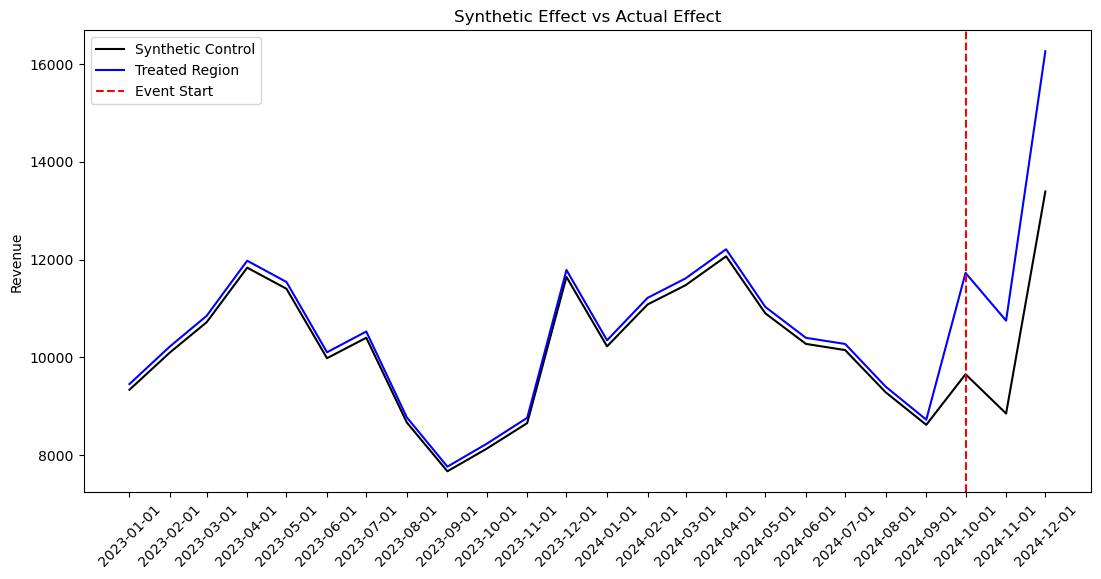

In [20]:
offset_plot=0.99

plt.figure(figsize=(13, 6))
plt.plot(df['Month'], df['Synthetic_Control']*offset_plot, color='k', label='Synthetic Control')
plt.plot(df['Month'], df[treated_region], color='b', label='Treated Region')
plt.axvline(event_start, label='Event Start', color='r', linestyle='--')
plt.legend(loc='upper left')
plt.xticks(df['Month'], rotation=45)
plt.ylabel('Revenue')
plt.title('Synthetic Effect vs Actual Effect')
plt.show()

In [27]:
df["Treatment Effect"] = df[treated_region] - df['Synthetic_Control']
postperiod = df[df['Month']>=pd.to_datetime(event_start)]
att=postperiod['Treatment Effect'].mean()
att_uplift = att/postperiod['Synthetic_Control'].mean()

print(f'Average Treatment Effect: {att:.2f}')
print(f'% of Uplift: {att_uplift:.2%}')

Average Treatment Effect: 2173.78
% of Uplift: 20.24%


**Observation**

- the uplift is also close to ground truth 20%. Note, based on the previous trend, the treated and synthetic data are almost identical. Hence, the gap between this two after the event are attributed to the treatment effect. If there was any difference in the data prior to event, we will need to use DID.

#### Reshape the data (Month-x-Region for each row) and estimate impacts using DiD

In [10]:
# TO-DO Reshape (melt) the DataFrame into a long format: One row per month-x-region combination
df_long=pd.melt(df, id_vars='Month', value_vars=control_regions+[treated_region], value_name='Revenue', var_name='Region')

# TO-DO: Set up DiD. You want indicators for the post period, treated region, and their interaction. 
df_long['treated']=np.where(df_long['Region']==treated_region, 1, 0)
df_long['post']=np.where(df_long['Month']>=event_start, 1, 0)
df_long['post_treated']=df_long['treated']*df_long['post']

# TO-DO: Fit a difference-in-differences model using statsmodels
formula='Revenue~treated+post+post_treated'
did_model=smf.ols(formula=formula, data=df_long).fit()

# TO-DO Calculate the average treatment effect, estimated baseline revenue, and percentage increase 
did_att = did_model.params['post_treated']
did_baseline=df_long[df_long['post_treated']==1]['Revenue'].mean()-did_att
did_pct = did_att/did_baseline

print(f'Average Treatment Effect: {did_att:.2f}')
print(f'Estimated Baseline Revenue: ${did_baseline:.2f}')
print(f'Percentage of Uplift: {did_pct:.2%}')

Average Treatment Effect: 3152.67
Estimated Baseline Revenue: $9759.88
Percentage of Uplift: 32.30%


In [8]:
print(did_model.summary())

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     2.916
Date:                Fri, 05 Dec 2025   Prob (F-statistic):             0.0350
Time:                        14:35:34   Log-Likelihood:                -2123.3
No. Observations:                 240   AIC:                             4255.
Df Residuals:                     236   BIC:                             4268.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     1.043e+04    123.422     84.535   

## Observation:
With a coefficient of $3,152 on treated:post, that means our DiD model estimated an increase of 32.0%, much higher than the 20% ground truth.

# Overall

The winner goes to Synthetic Control (lasso regression) and Event Study for this exercise. 

This doesn't mean that Synthetic Control and Event Study models are always better than Difference-in-Differences models, but for this particular dataset, DiD did not perform as well.